En equipo:

- Elaborar ejemplos de transformación de datos a través de gráficas y medidas (Z-score, Min-Max y Robust Scalling)
- Mostrar ejemplos de transformación Log, Box-Cox y Yeo-Johnson, utilizando diferentes parámetros
- Simular datos de Exposición, Número de siniestros y Severidad, con el objetivo de mostrar tendencias, estacionalidades y ciclos. Incluir el impacto en Frecuencia y en Inflación.
- Calcular ciclos a través de senos y cosenos y mostrarlo en la gráfica de frecuencia y de inflación
- Realizar medias móviles de Frecuencia y de severidad y agregarlas a la gráfica

Subir un documento PDF por equipo con el ejercicio, agregando comentarios y conclusiones
Incluir nombres de integrantes del equipo

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import warnings
from scipy import stats
from scipy.stats import boxcox, yeojohnson, shapiro

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

In [65]:
# Simulamos datos para generar las transformaciones 

# Dataset de siniestros con fechas (para análisis temporal)
np.random.seed(42)
n = 3000

# Simulación de siniestros y características del conductor y vehículo
df_sin = pd.DataFrame({
    'edad_conductor': np.random.randint(18, 80, n),
    'imc': np.random.normal(26, 5, n).clip(15, 45),  # Índice Masa Corporal
    'antiguedad_vehiculo': np.random.randint(0, 20, n),
    'suma_asegurada': np.random.lognormal(15, 0.4, n),
    'prima_anual': np.random.lognormal(11.2, 0.4, n),
    'monto_siniestros_previos': np.random.lognormal(8, 1, n) * np.random.poisson(0.3, n),
})

print(f"📋 Dataset: {df_sin.shape}")
df_sin.head(5)


📋 Dataset: (3000, 6)


,edad_conductor,imc,antiguedad_vehiculo,suma_asegurada,prima_anual,monto_siniestros_previos
0,56,23.105184,5,2.837778e+06,81600.078462,1512.172048
1,69,26.318442,12,3.249512e+06,63112.408081,0.000000
2,46,28.359807,19,2.932863e+06,45262.882080,0.000000
3,32,26.696077,19,2.532053e+06,56336.487499,0.000000
4,60,32.030767,11,1.657286e+06,124015.236567,736.705337


### Elaborar ejemplos de transformación de datos a través de gráficas y medidas (Z-score, Min-Max y Robust Scalling)

In [66]:
# Realizamos el escalamiento de la variable 'prima_anual' utilizando diferentes métodos y comparamos sus estadísticas descriptivas
variables_escalamiento = ['prima_anual']

# Definimos los escaladores a aplicar
scalers = {
    'Min-Max Scaler':   MinMaxScaler(),
    'Z-Score (Standard)': StandardScaler(),
    'Robust Scaler':    RobustScaler()
}

# Diccionario para almacenar los resultados de las estadísticas descriptivas de las variables escaladas
resultados_scaling = {}

# Aplicamos cada escalador a las variables seleccionadas y almacenamos los resultados en un nuevo dataframe
for nombre, scaler in scalers.items():
    datos_escalar = df_sin[variables_escalamiento]
    datos_escalados = scaler.fit_transform(datos_escalar)
    resultados_scaling[nombre] = pd.DataFrame(datos_escalados, columns=variables_escalamiento)

    
# Calculamos las estadísticas descriptivas para cada tipo de escalamiento
for variable in variables_escalamiento:
    print("=" * 70)
    print(' '*10 +f"TABLA COMPARATIVA: {variable} después de escalar")
    print("=" * 70)
    print(f"{'Método':<25} {'Media':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
    print("-" * 70)
    
    # 1. Estadísticas de los datos originales
    original_mean = df_sin[variable].mean()
    original_std  = df_sin[variable].std()
    original_min  = df_sin[variable].min()
    original_max  = df_sin[variable].max()
    print(f"{'Original':<25} {original_mean:>10.2f} {original_std:>10.2f} {original_min:>10.2f} {original_max:>10.2f}")

       # 2. Estadísticas de cada método de escalado
    for nombre, df_escalado in resultados_scaling.items():
        s = df_escalado[variable]
        print(f"{nombre:<25} {s.mean():>10.4f} {s.std():>10.4f} {s.min():>10.4f} {s.max():>10.4f}")
    print("\n")


          TABLA COMPARATIVA: prima_anual después de escalar
Método                         Media        Std        Min        Max
----------------------------------------------------------------------
Original                    78594.54   32939.28   14448.99  258387.36
Min-Max Scaler                0.2630     0.1350     0.0000     1.0000
Z-Score (Standard)            0.0000     1.0002    -1.9477     5.4592
Robust Scaler                 0.1381     0.8107    -1.4406     4.5630




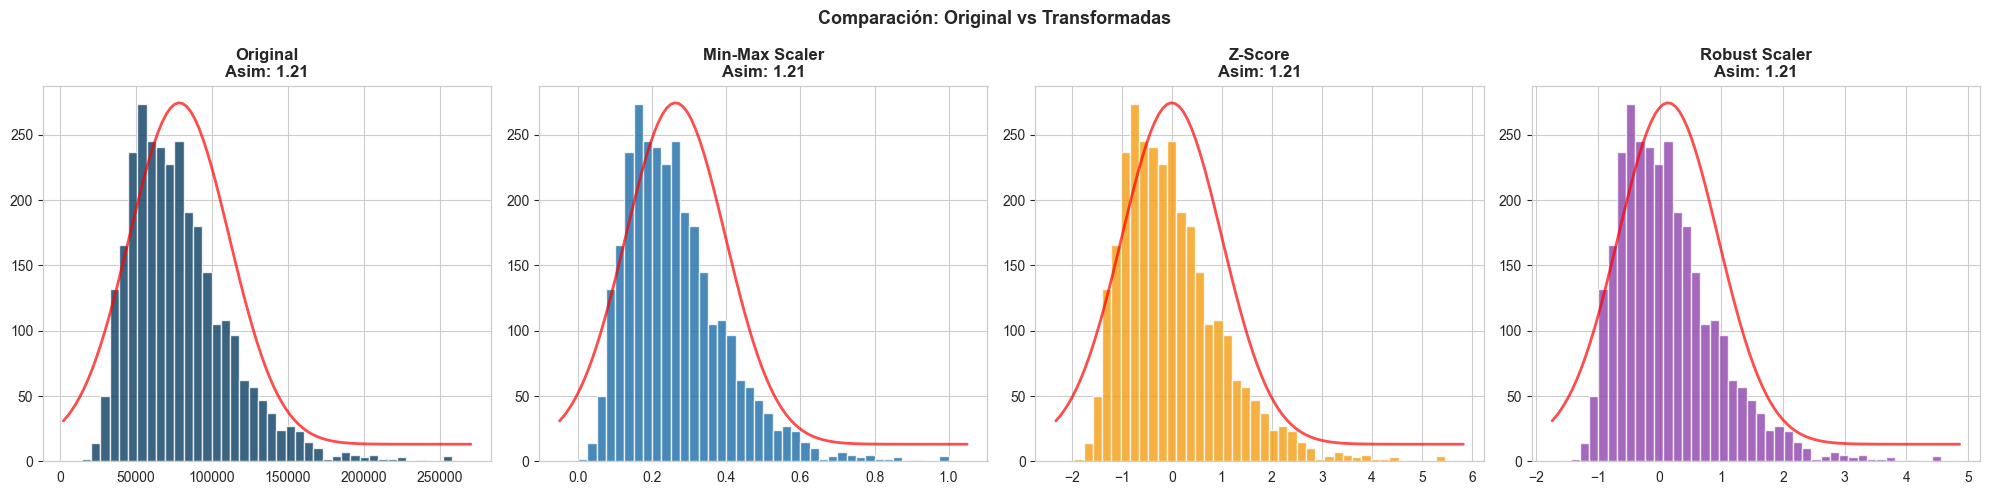

In [67]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
datos = [df_sin['prima_anual'], resultados_scaling['Min-Max Scaler']['prima_anual'], resultados_scaling['Z-Score (Standard)']['prima_anual'], resultados_scaling['Robust Scaler']['prima_anual']]
labels = [f'Original\nAsim: {stats.skew(df_sin["prima_anual"]):.2f}',
          f'Min-Max Scaler\nAsim: {stats.skew(resultados_scaling["Min-Max Scaler"]["prima_anual"]):.2f}',
          f'Z-Score\nAsim: {stats.skew(resultados_scaling["Z-Score (Standard)"]["prima_anual"]):.2f}',
          f'Robust Scaler\nAsim: {stats.skew(resultados_scaling["Robust Scaler"]["prima_anual"]):.2f}',]
colors = ['#0A3D62', '#1B6CA8', '#F39C12', '#8E44AD']

for ax, d, lab, c in zip(axes, datos, labels, colors):
    ax.hist(d, bins=40, color=c, alpha=0.8, edgecolor='white')
    ax.set_title(lab, fontweight='bold')
    # Agregar curva normal teórica
    xmin, xmax = ax.get_xlim()
    x_norm = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x_norm, d.mean(), d.std())
    ax_twin = ax.twinx()
    ax_twin.plot(x_norm, p, 'r-', linewidth=2, alpha=0.7, label='Normal')
    ax_twin.set_ylabel('')
    ax_twin.set_yticks([])

plt.suptitle('Comparación: Original vs Transformadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Mostrar ejemplos de transformación Log, Box-Cox y Yeo-Johnson, utilizando diferentes parámetros

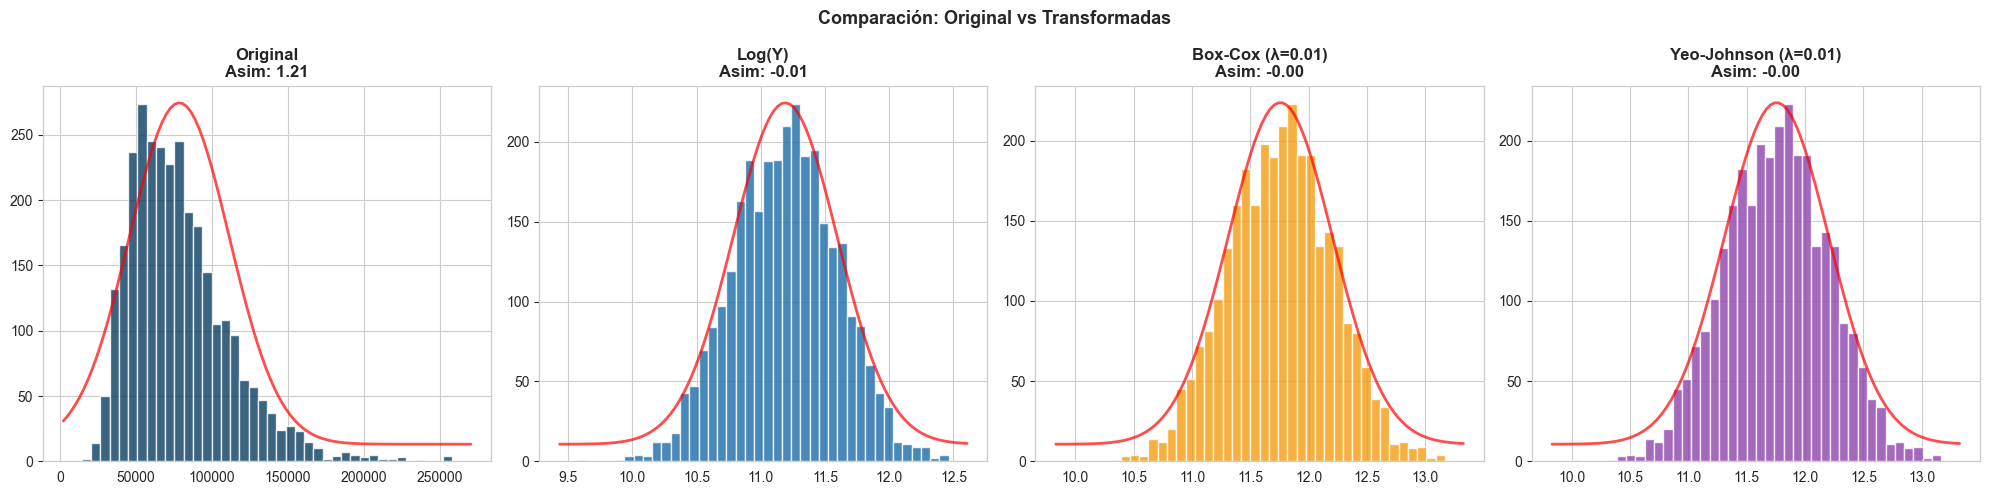

TEST DE NORMALIDAD (Shapiro-Wilk)
H0: Los datos siguen distribución normal
Si p-valor > 0.05 → No rechazamos normalidad
Original        | Estadístico: 0.9314 | p-valor: 0.000000 | ❌ No normal
Box-Cox         | Estadístico: 0.9972 | p-valor: 0.557908 | ✅ Normal
Log(Y)          | Estadístico: 0.9972 | p-valor: 0.559962 | ✅ Normal
Yeo-Johnson     | Estadístico: 0.9972 | p-valor: 0.557892 | ✅ Normal


In [68]:
# Parámetros optimos para Box-Cox y Yeo-Johnson
y = df_sin['prima_anual']
y_boxcox, lambda_optimo = boxcox(y)
y_yj, lambda_yj = yeojohnson(y)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
datos = [y, np.log(y), y_boxcox, y_yj]
labels = [f'Original\nAsim: {stats.skew(y):.2f}',
          f'Log(Y)\nAsim: {stats.skew(np.log(y)):.2f}',
          f'Box-Cox (λ={lambda_optimo:.2f})\nAsim: {stats.skew(y_boxcox):.2f}',
          f'Yeo-Johnson (λ={lambda_yj:.2f})\nAsim: {stats.skew(y_yj):.2f}',]
colors = ['#0A3D62', '#1B6CA8', '#F39C12', '#8E44AD']

for ax, d, lab, c in zip(axes, datos, labels, colors):
    ax.hist(d, bins=40, color=c, alpha=0.8, edgecolor='white')
    ax.set_title(lab, fontweight='bold')
    # Agregar curva normal teórica
    xmin, xmax = ax.get_xlim()
    x_norm = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x_norm, d.mean(), d.std())
    ax_twin = ax.twinx()
    ax_twin.plot(x_norm, p, 'r-', linewidth=2, alpha=0.7, label='Normal')
    ax_twin.set_ylabel('')
    ax_twin.set_yticks([])

plt.suptitle('Comparación: Original vs Transformadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

variables_test = {
    'Original': df_sin['prima_anual'].sample(500, random_state=70),
    'Box-Cox': pd.Series(y_boxcox).sample(500, random_state=70),
    'Log(Y)': pd.Series(np.log(df_sin['prima_anual'])).sample(500, random_state=70),
    'Yeo-Johnson': pd.Series(y_yj).sample(500, random_state=70),
}

print("=" * 55)
print("TEST DE NORMALIDAD (Shapiro-Wilk)")
print("H0: Los datos siguen distribución normal")
print("Si p-valor > 0.05 → No rechazamos normalidad")
print("=" * 55)

for nombre, data in variables_test.items():
    stat, p_valor = shapiro(data)
    decision = "✅ Normal" if p_valor > 0.05 else "❌ No normal"
    print(f"{nombre:15s} | Estadístico: {stat:.4f} | p-valor: {p_valor:.6f} | {decision}")

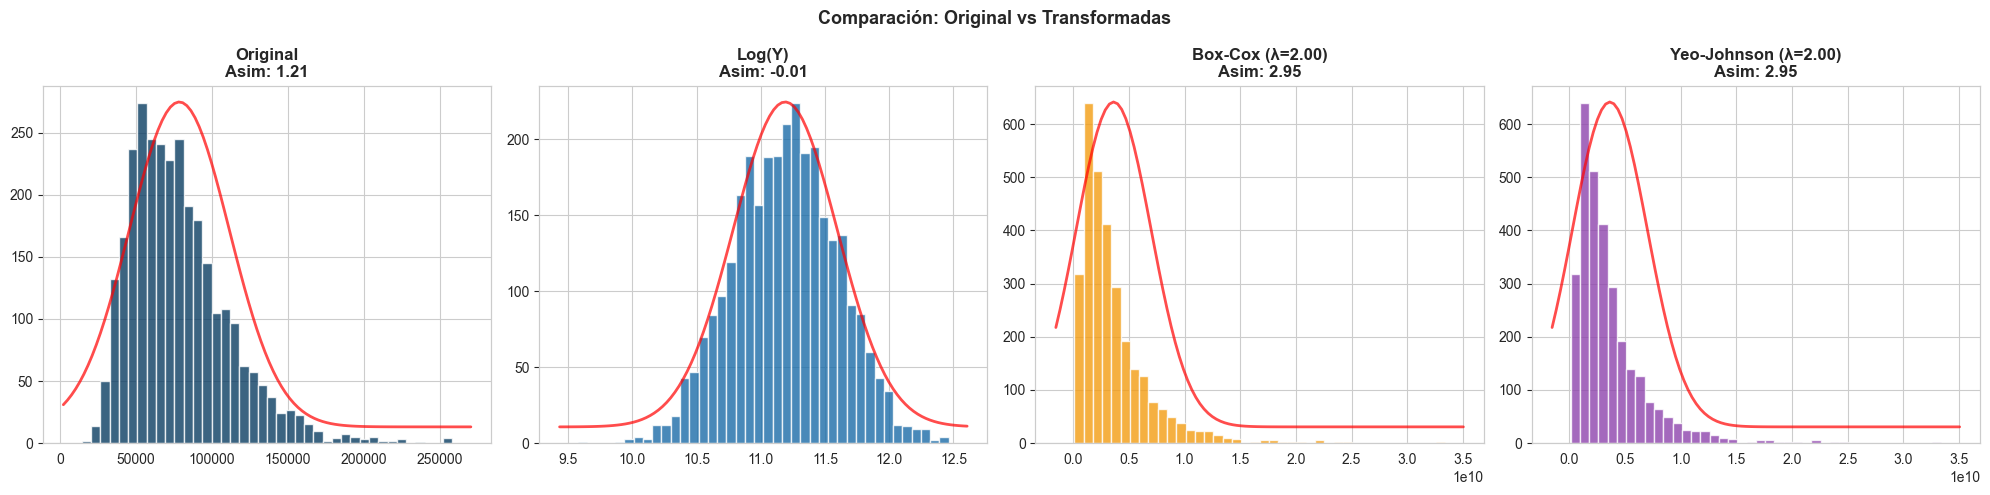

TEST DE NORMALIDAD (Shapiro-Wilk)
H0: Los datos siguen distribución normal
Si p-valor > 0.05 → No rechazamos normalidad
Original        | Estadístico: 0.9314 | p-valor: 0.000000 | ❌ No normal
Box-Cox         | Estadístico: 0.7620 | p-valor: 0.000000 | ❌ No normal
Log(Y)          | Estadístico: 0.9972 | p-valor: 0.559962 | ✅ Normal
Yeo-Johnson     | Estadístico: 0.7620 | p-valor: 0.000000 | ❌ No normal


In [69]:
# Lambda fijo para Box-Cox y Yeo-Johnson (Mayor que 0)
y = df_sin['prima_anual']
y_boxcox  = boxcox(y, lmbda = 2)
y_yj = yeojohnson(y, lmbda = 2)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
datos = [y, np.log(y), y_boxcox, y_yj]
labels = [f'Original\nAsim: {stats.skew(y):.2f}',
          f'Log(Y)\nAsim: {stats.skew(np.log(y)):.2f}',
          f'Box-Cox (λ={2:.2f})\nAsim: {stats.skew(y_boxcox):.2f}',
          f'Yeo-Johnson (λ={2:.2f})\nAsim: {stats.skew(y_yj):.2f}',]
colors = ['#0A3D62', '#1B6CA8', '#F39C12', '#8E44AD']

for ax, d, lab, c in zip(axes, datos, labels, colors):
    ax.hist(d, bins=40, color=c, alpha=0.8, edgecolor='white')
    ax.set_title(lab, fontweight='bold')
    # Agregar curva normal teórica
    xmin, xmax = ax.get_xlim()
    x_norm = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x_norm, d.mean(), d.std())
    ax_twin = ax.twinx()
    ax_twin.plot(x_norm, p, 'r-', linewidth=2, alpha=0.7, label='Normal')
    ax_twin.set_ylabel('')
    ax_twin.set_yticks([])

plt.suptitle('Comparación: Original vs Transformadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

variables_test = {
    'Original': df_sin['prima_anual'].sample(500, random_state=70),
    'Box-Cox': pd.Series(y_boxcox).sample(500, random_state=70),
    'Log(Y)': pd.Series(np.log(df_sin['prima_anual'])).sample(500, random_state=70),
    'Yeo-Johnson': pd.Series(y_yj).sample(500, random_state=70),
}

print("=" * 55)
print("TEST DE NORMALIDAD (Shapiro-Wilk)")
print("H0: Los datos siguen distribución normal")
print("Si p-valor > 0.05 → No rechazamos normalidad")
print("=" * 55)

for nombre, data in variables_test.items():
    stat, p_valor = shapiro(data)
    decision = "✅ Normal" if p_valor > 0.05 else "❌ No normal"
    print(f"{nombre:15s} | Estadístico: {stat:.4f} | p-valor: {p_valor:.6f} | {decision}")

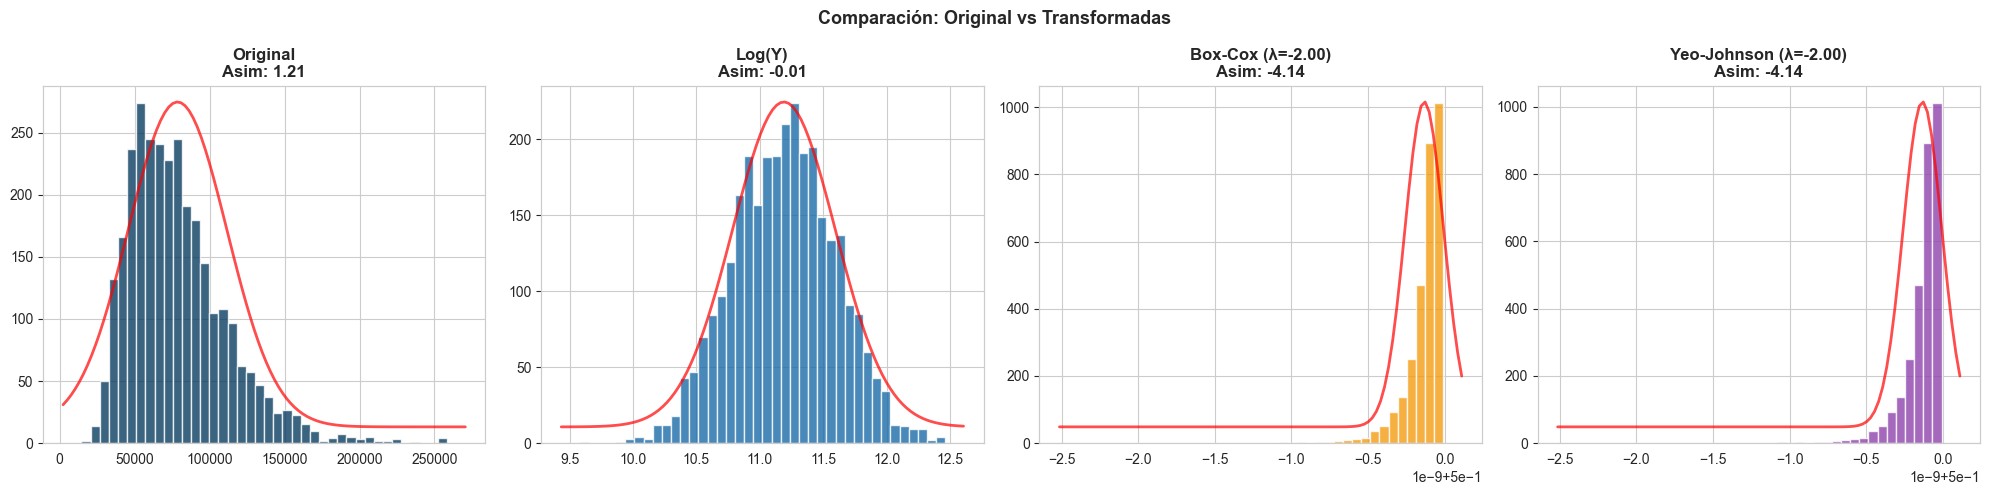

TEST DE NORMALIDAD (Shapiro-Wilk)
H0: Los datos siguen distribución normal
Si p-valor > 0.05 → No rechazamos normalidad
Original        | Estadístico: 0.9314 | p-valor: 0.000000 | ❌ No normal
Box-Cox         | Estadístico: 0.7725 | p-valor: 0.000000 | ❌ No normal
Log(Y)          | Estadístico: 0.9972 | p-valor: 0.559962 | ✅ Normal
Yeo-Johnson     | Estadístico: 0.7725 | p-valor: 0.000000 | ❌ No normal


In [70]:
# Lambda fijo para Box-Cox y Yeo-Johnson (Menor que 0)
y = df_sin['prima_anual']
y_boxcox  = boxcox(y, lmbda = -2)
y_yj = yeojohnson(y, lmbda = -2)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
datos = [y, np.log(y), y_boxcox, y_yj]
labels = [f'Original\nAsim: {stats.skew(y):.2f}',
          f'Log(Y)\nAsim: {stats.skew(np.log(y)):.2f}',
          f'Box-Cox (λ={-2:.2f})\nAsim: {stats.skew(y_boxcox):.2f}',
          f'Yeo-Johnson (λ={-2:.2f})\nAsim: {stats.skew(y_yj):.2f}',]
colors = ['#0A3D62', '#1B6CA8', '#F39C12', '#8E44AD']

for ax, d, lab, c in zip(axes, datos, labels, colors):
    ax.hist(d, bins=40, color=c, alpha=0.8, edgecolor='white')
    ax.set_title(lab, fontweight='bold')
    # Agregar curva normal teórica
    xmin, xmax = ax.get_xlim()
    x_norm = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x_norm, d.mean(), d.std())
    ax_twin = ax.twinx()
    ax_twin.plot(x_norm, p, 'r-', linewidth=2, alpha=0.7, label='Normal')
    ax_twin.set_ylabel('')
    ax_twin.set_yticks([])

plt.suptitle('Comparación: Original vs Transformadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

variables_test = {
    'Original': df_sin['prima_anual'].sample(500, random_state=70),
    'Box-Cox': pd.Series(y_boxcox).sample(500, random_state=70),
    'Log(Y)': pd.Series(np.log(df_sin['prima_anual'])).sample(500, random_state=70),
    'Yeo-Johnson': pd.Series(y_yj).sample(500, random_state=70),
}

print("=" * 55)
print("TEST DE NORMALIDAD (Shapiro-Wilk)")
print("H0: Los datos siguen distribución normal")
print("Si p-valor > 0.05 → No rechazamos normalidad")
print("=" * 55)

for nombre, data in variables_test.items():
    stat, p_valor = shapiro(data)
    decision = "✅ Normal" if p_valor > 0.05 else "❌ No normal"
    print(f"{nombre:15s} | Estadístico: {stat:.4f} | p-valor: {p_valor:.6f} | {decision}")

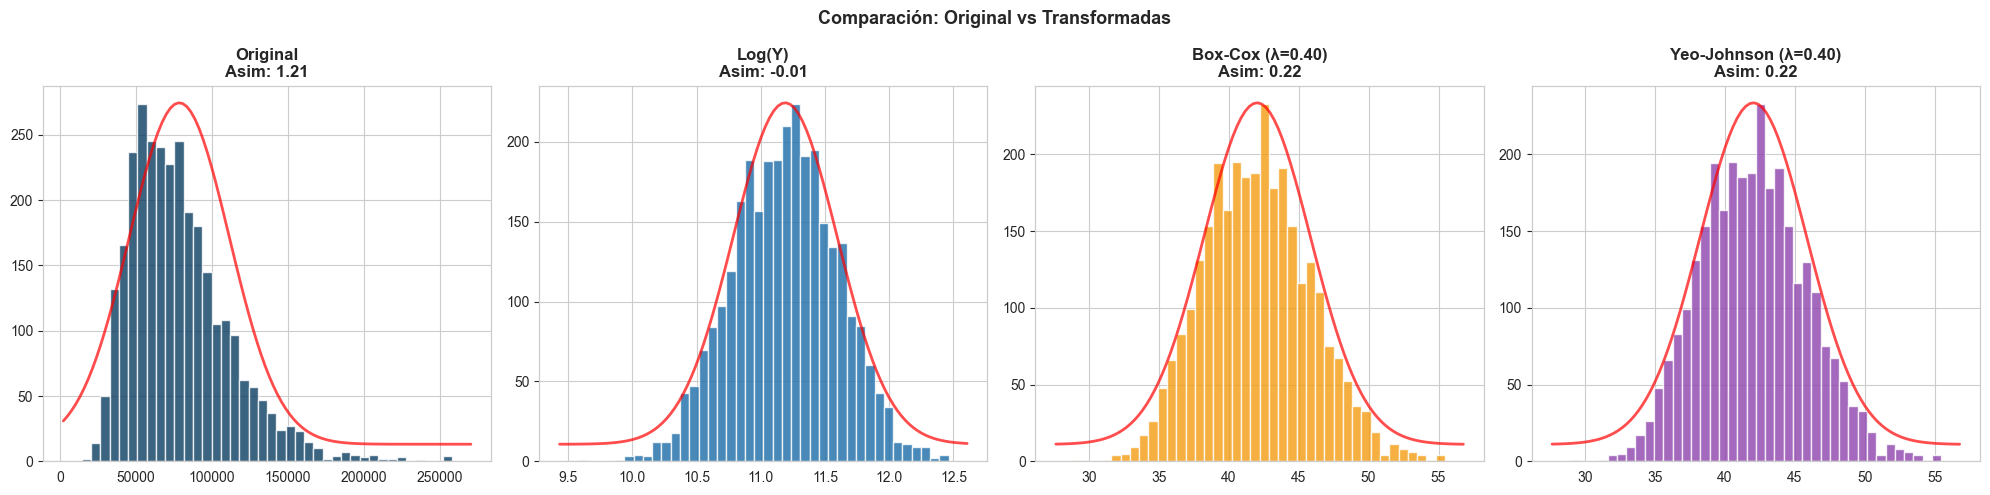

TEST DE NORMALIDAD (Shapiro-Wilk)
H0: Los datos siguen distribución normal
Si p-valor > 0.05 → No rechazamos normalidad
Original        | Estadístico: 0.9314 | p-valor: 0.000000 | ❌ No normal
Box-Cox         | Estadístico: 0.9945 | p-valor: 0.067781 | ✅ Normal
Log(Y)          | Estadístico: 0.9972 | p-valor: 0.559962 | ✅ Normal
Yeo-Johnson     | Estadístico: 0.9945 | p-valor: 0.067761 | ✅ Normal


In [71]:
# Lambda fijo para Box-Cox y Yeo-Johnson (Mayor que 0)
y = df_sin['prima_anual']
y_boxcox  = boxcox(y, lmbda = 0.2)
y_yj = yeojohnson(y, lmbda = 0.2)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
datos = [y, np.log(y), y_boxcox, y_yj]
labels = [f'Original\nAsim: {stats.skew(y):.2f}',
          f'Log(Y)\nAsim: {stats.skew(np.log(y)):.2f}',
          f'Box-Cox (λ={0.4:.2f})\nAsim: {stats.skew(y_boxcox):.2f}',
          f'Yeo-Johnson (λ={0.4:.2f})\nAsim: {stats.skew(y_yj):.2f}',]
colors = ['#0A3D62', '#1B6CA8', '#F39C12', '#8E44AD']

for ax, d, lab, c in zip(axes, datos, labels, colors):
    ax.hist(d, bins=40, color=c, alpha=0.8, edgecolor='white')
    ax.set_title(lab, fontweight='bold')
    # Agregar curva normal teórica
    xmin, xmax = ax.get_xlim()
    x_norm = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x_norm, d.mean(), d.std())
    ax_twin = ax.twinx()
    ax_twin.plot(x_norm, p, 'r-', linewidth=2, alpha=0.7, label='Normal')
    ax_twin.set_ylabel('')
    ax_twin.set_yticks([])

plt.suptitle('Comparación: Original vs Transformadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

variables_test = {
    'Original': df_sin['prima_anual'].sample(500, random_state=70),
    'Box-Cox': pd.Series(y_boxcox).sample(500, random_state=70),
    'Log(Y)': pd.Series(np.log(df_sin['prima_anual'])).sample(500, random_state=70),
    'Yeo-Johnson': pd.Series(y_yj).sample(500, random_state=70),
}

print("=" * 55)
print("TEST DE NORMALIDAD (Shapiro-Wilk)")
print("H0: Los datos siguen distribución normal")
print("Si p-valor > 0.05 → No rechazamos normalidad")
print("=" * 55)

for nombre, data in variables_test.items():
    stat, p_valor = shapiro(data)
    decision = "✅ Normal" if p_valor > 0.05 else "❌ No normal"
    print(f"{nombre:15s} | Estadístico: {stat:.4f} | p-valor: {p_valor:.6f} | {decision}")

### Simular datos de Exposición, Número de siniestros y Severidad, con el objetivo de mostrar tendencias, estacionalidades y ciclos. Incluir el impacto en Frecuencia y en Inflación.

In [72]:
df_sin['exposicion'] = np.random.uniform(0.1, 1.0, n)
df_sin['n_siniestros_previos'] = np.random.poisson(0.3, n)
df_sin['monto_siniestro'] = np.random.lognormal(12, 2, n)

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configuración inicial y línea de tiempo (5 años de datos mensuales)
np.random.seed(42)
meses = pd.date_range(start="2021-01-01", end="2025-12-01", freq="MS")
n_meses = len(meses)

# 2. Definición de Componentes Temporales
t = np.arange(n_meses)  # Vector de tiempo (0, 1, 2...)

# Tendencia de crecimiento del negocio y del riesgo
tendencia_expo = 100 + 2 * t  
# Estacionalidad: Seno con periodo de 12 meses (picos en invierno/verano por ejemplo)
estacionalidad = np.sin(2 * np.pi * meses.month / 12) * 0.15
# Ciclo económico/climatológico: Onda más larga (ej. ciclo de 36 meses)
ciclo = np.cos(2 * np.pi * t / 36) * 0.10
# Inflación: 5% anualizado (convertido a mensual: ~0.41%)
inflacion_mensual = 0.05 / 12
inflacion_acumulada = (1 + inflacion_mensual) ** t

# 3. Simulación de Datos por Mes
Data_historica = []

for i, mes in enumerate(meses):
    # --- EXPOSICIÓN ---
    # El número de pólizas expuestas crece con la tendencia
    exposicion_total = int(tendencia_expo[i] + np.random.normal(0, 5))
    
    # --- FRECUENCIA (Impacto de Estacionalidad y Ciclo) ---
    # La tasa base de siniestralidad por póliza se altera por el ciclo y la estacionalidad
    frecuencia_base = 0.20  # 20% de probabilidad base de siniestro por exposición
    lambda_mes = frecuencia_base * (1 + estacionalidad[i] + ciclo[i])
    
    # Generar número de siniestros para las pólizas de este mes
    n_siniestros = np.random.poisson(lambda_mes * exposicion_total)
    
    # --- SEVERIDAD (Impacto de la Inflación) ---
    if n_siniestros > 0:
        # El parámetro mu de la Lognormal se ajusta con la inflación acumulada
        # log(valor_base * inflacion) = log(valor_base) + log(inflacion)
        mu_base = 8.5  
        mu_ajustado = mu_base + np.log(inflacion_acumulada[i])
        sigma = 0.7
        
        montos = np.random.lognormal(mu_ajustado, sigma, n_siniestros)
        monto_total = montos.sum()
        severidad_media = montos.mean()
    else:
        monto_total = 0
        severidad_media = 0
        
    Data_historica.append({
        'Fecha': mes,
        'Exposicion': exposicion_total,
        'N_Siniestros': n_siniestros,
        'Monto_Total': monto_total,
        'Severidad_Media': severidad_media,
        'Frecuencia_Observada': n_siniestros / exposicion_total if exposicion_total > 0 else 0
    })

df = pd.DataFrame(Data_historica).set_index('Fecha')

# Mostrar las primeras filas del resultado
print(df.head())

            Exposicion  N_Siniestros    Monto_Total  Severidad_Media  \
Fecha                                                                  
2021-01-01         102            27  128119.571363      4745.169310   
2021-02-01          98            17   92257.132482      5426.890146   
2021-03-01         105            31  198426.939487      6400.869016   
2021-04-01         101            29  167647.592695      5780.951472   
2021-05-01         113            22  140553.989773      6388.817717   

            Frecuencia_Observada  
Fecha                             
2021-01-01              0.264706  
2021-02-01              0.173469  
2021-03-01              0.295238  
2021-04-01              0.287129  
2021-05-01              0.194690  


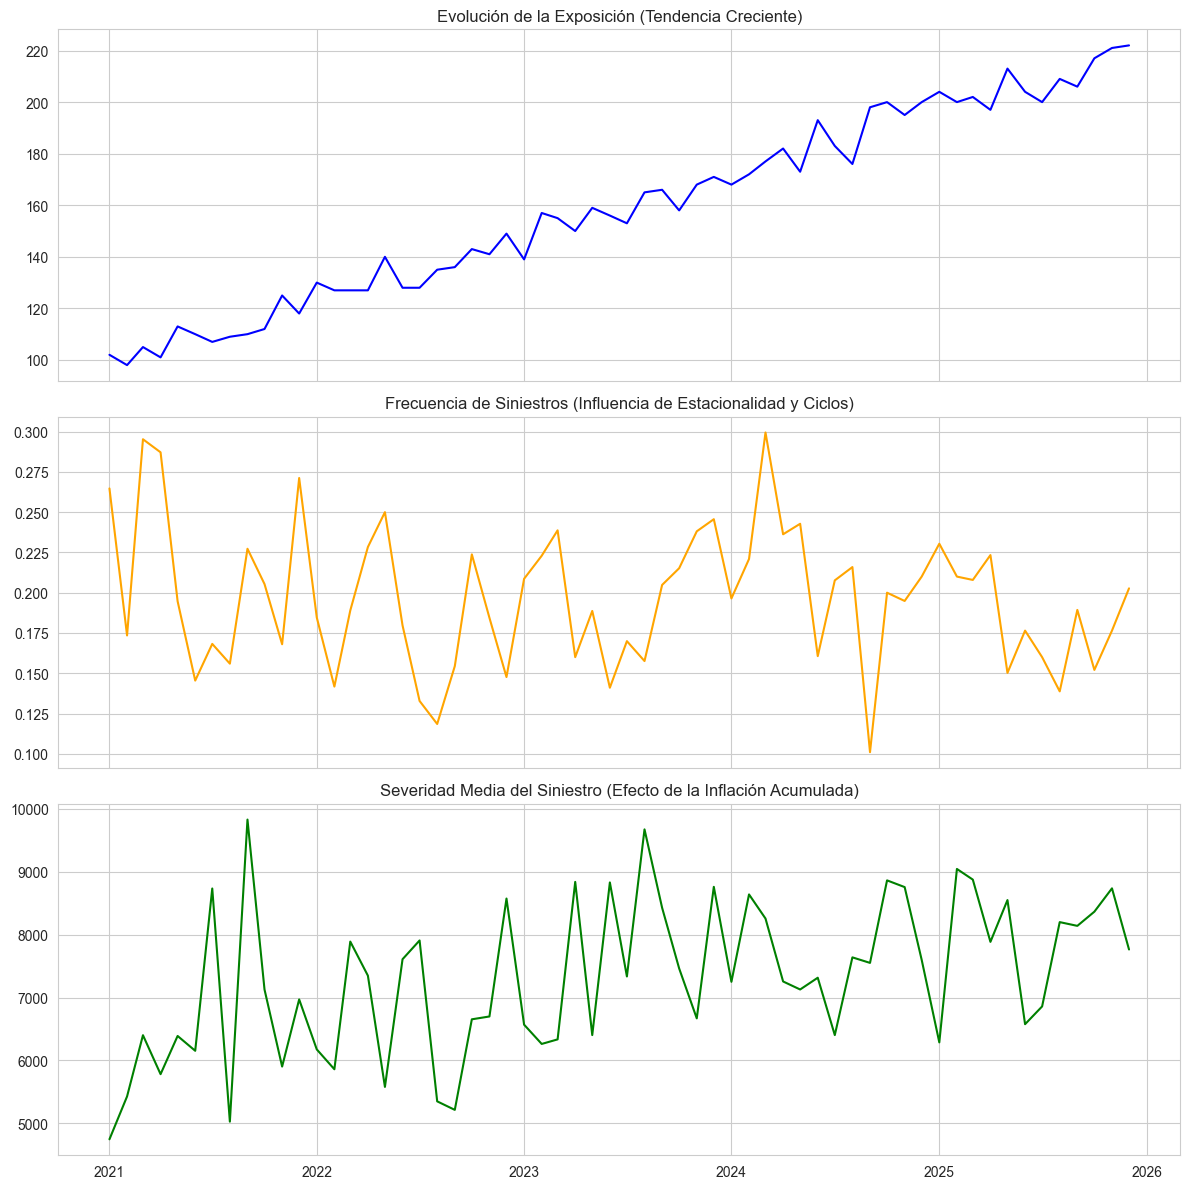

In [74]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Gráfica 1: Exposición (Tendencia)
axes[0].plot(df.index, df['Exposicion'], color='blue', label='Exposición (Pólizas)')
axes[0].set_title('Evolución de la Exposición (Tendencia Creciente)')
axes[0].grid(True)

# Gráfica 2: Frecuencia con Estacionalidad y Ciclo
axes[1].plot(df.index, df['Frecuencia_Observada'], color='orange', label='Frecuencia Siniestral')
axes[1].set_title('Frecuencia de Siniestros (Influencia de Estacionalidad y Ciclos)')
axes[1].grid(True)

# Gráfica 3: Severidad Media (Inflación)
axes[2].plot(df.index, df['Severidad_Media'], color='green', label='Severidad Media')
axes[2].set_title('Severidad Media del Siniestro (Efecto de la Inflación Acumulada)')
axes[2].grid(True)

plt.tight_layout()
plt.show()

### Calcular ciclos a través de senos y cosenos y mostrarlo en la gráfica de frecuencia y de inflación

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configuración de la línea de tiempo (5 años mensuales)
np.random.seed(42)
meses = pd.date_range(start="2021-01-01", end="2025-12-01", freq="MS")
n_meses = len(meses)
t = np.arange(n_meses)  # Vector de tiempo: 0, 1, 2... hasta 59

# ==========================================
# 2. CÁLCULO DE CICLOS DE FRECUENCIA
# ==========================================
frecuencia_base = 0.20  # 20% tasa base

# Estacionalidad Anual (Seno, periodo = 12 meses, amplitud = 15%)
estacionalidad_anual = np.sin(2 * np.pi * t / 12) * 0.15

# Ciclo Plurianual/Económico (Coseno, periodo = 36 meses, amplitud = 10%)
ciclo_plurianual = np.cos(2 * np.pi * t / 36) * 0.10

# Frecuencia Teórica Total (Multiplicativa)
frecuencia_teorica = frecuencia_base * (1 + estacionalidad_anual + ciclo_plurianual)


# ==========================================
# 3. CÁLCULO DE INFLACIÓN Y CICLOS DE SEVERIDAD
# ==========================================
inflacion_anual = 0.06  # 6% anual
inflacion_mensual = inflacion_anual / 12
inflacion_acumulada = (1 + inflacion_mensual) ** t

# Ciclo de Mercado en Costos (Seno, periodo = 24 meses, amplitud = 8%)
# Esto modela que los costos suben/bajan cíclicamente independientemente de la inflación
ciclo_costos = np.sin(2 * np.pi * t / 24) * 0.08

# Severidad Teórica (Uniendo Inflación + Ciclo de Costos)
severidad_base = 5000  # Costo medio inicial
severidad_teorica = severidad_base * inflacion_acumulada * (1 + ciclo_costos)


# ==========================================
# 4. SIMULACIÓN DE DATOS REALES (CON RUIDO)
# ==========================================
exposicion = 1000  # Pólizas fijas para aislar los efectos visuales
n_siniestros_simulados = np.random.poisson(frecuencia_teorica * exposicion)

severidad_simulada = []
for i, n_sin in enumerate(n_siniestros_simulados):
    if n_sin > 0:
        # Usamos lognormal para los costos reales distribuidos alrededor de la severidad teórica
        mu = np.log(severidad_teorica[i]) - 0.1  # Ajuste por media lognormal
        montos = np.random.lognormal(mu, 0.4, n_sin)
        severidad_simulada.append(montos.mean())
    else:
        severidad_simulada.append(0)

# Construir DataFrame
df = pd.DataFrame({
    'Frecuencia_Teorica': frecuencia_teorica,
    'Frecuencia_Observada': n_siniestros_simulados / exposicion,
    'Inflacion_Pura': severidad_base * inflacion_acumulada,
    'Severidad_Teorica_Con_Ciclo': severidad_teorica,
    'Severidad_Observada': severidad_simulada
}, index=meses)

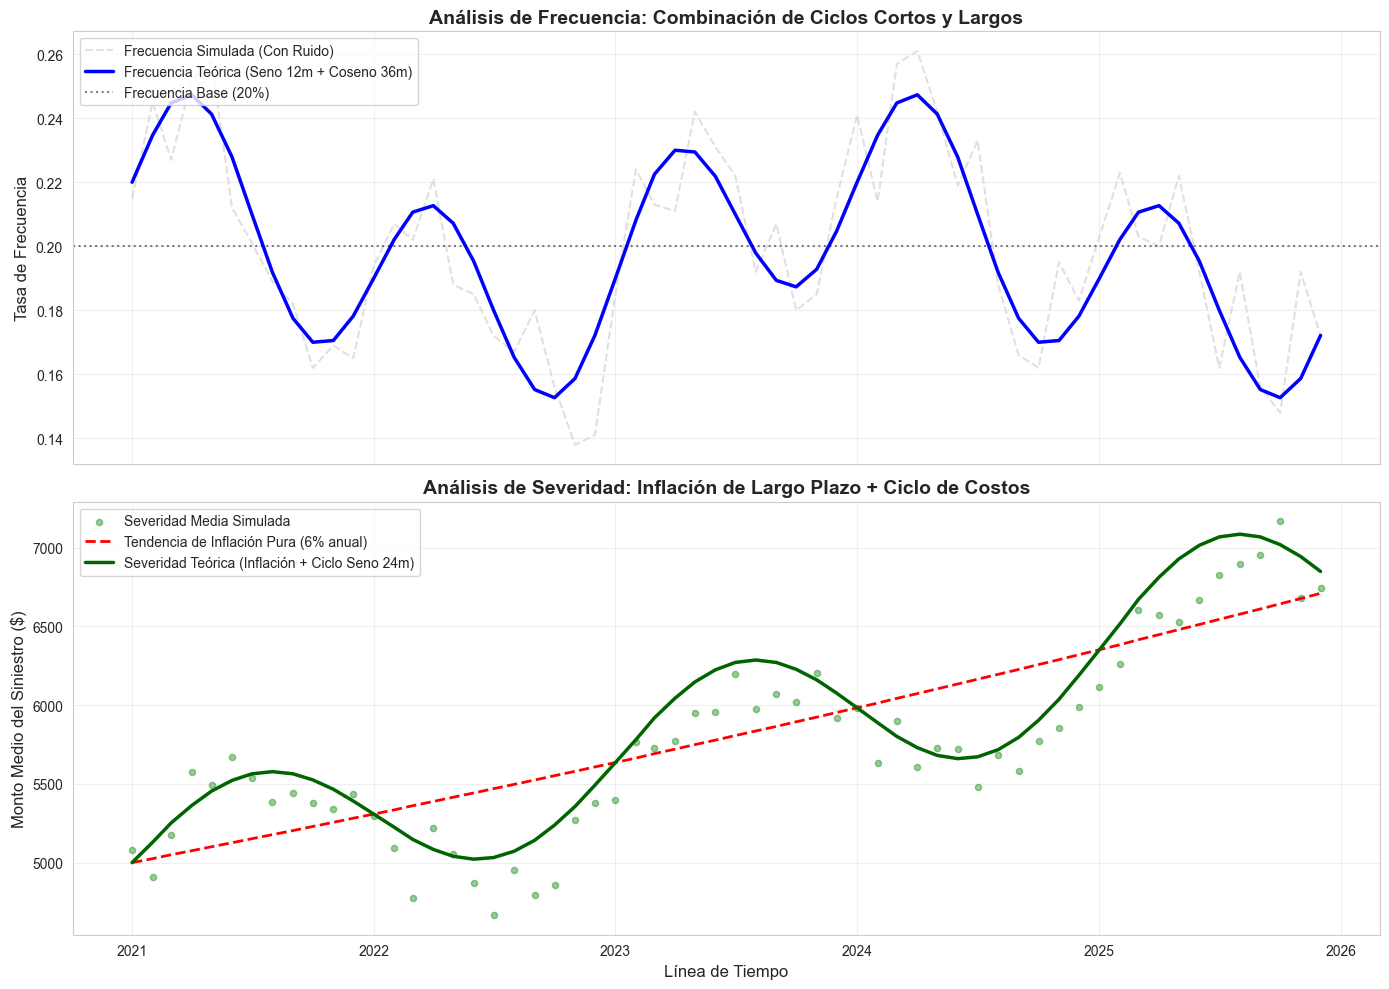

In [76]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# ----------------------------------------------------
# GRÁFICA 1: FRECUENCIA (Estacionalidad de 12 meses + Ciclo de 36 meses)
# ----------------------------------------------------
axes[0].plot(df.index, df['Frecuencia_Observada'], color='lightgray', linestyle='--', alpha=0.7, label='Frecuencia Simulada (Con Ruido)')
axes[0].plot(df.index, df['Frecuencia_Teorica'], color='blue', linewidth=2.5, label='Frecuencia Teórica (Seno 12m + Coseno 36m)')

# Añadir líneas guía para notar los ciclos plurianuales
axes[0].axhline(frecuencia_base, color='black', linestyle=':', alpha=0.5, label='Frecuencia Base (20%)')
axes[0].set_title('Análisis de Frecuencia: Combinación de Ciclos Cortos y Largos', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Tasa de Frecuencia', fontsize=12)
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# ----------------------------------------------------
# GRÁFICA 2: INFLACIÓN Y SEVERIDAD (Tendencia Exponencial + Ciclo de 24 meses)
# ----------------------------------------------------
axes[1].scatter(df.index, df['Severidad_Observada'], color='green', alpha=0.4, s=20, label='Severidad Media Simulada')
axes[1].plot(df.index, df['Inflacion_Pura'], color='red', linestyle='--', linewidth=2, label='Tendencia de Inflación Pura (6% anual)')
axes[1].plot(df.index, df['Severidad_Teorica_Con_Ciclo'], color='darkgreen', linewidth=2.5, label='Severidad Teórica (Inflación + Ciclo Seno 24m)')

axes[1].set_title('Análisis de Severidad: Inflación de Largo Plazo + Ciclo de Costos', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Monto Medio del Siniestro ($)', fontsize=12)
axes[1].set_xlabel('Línea de Tiempo', fontsize=12)
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Realizar medias móviles de Frecuencia y de severidad y agregarlas a la gráfica

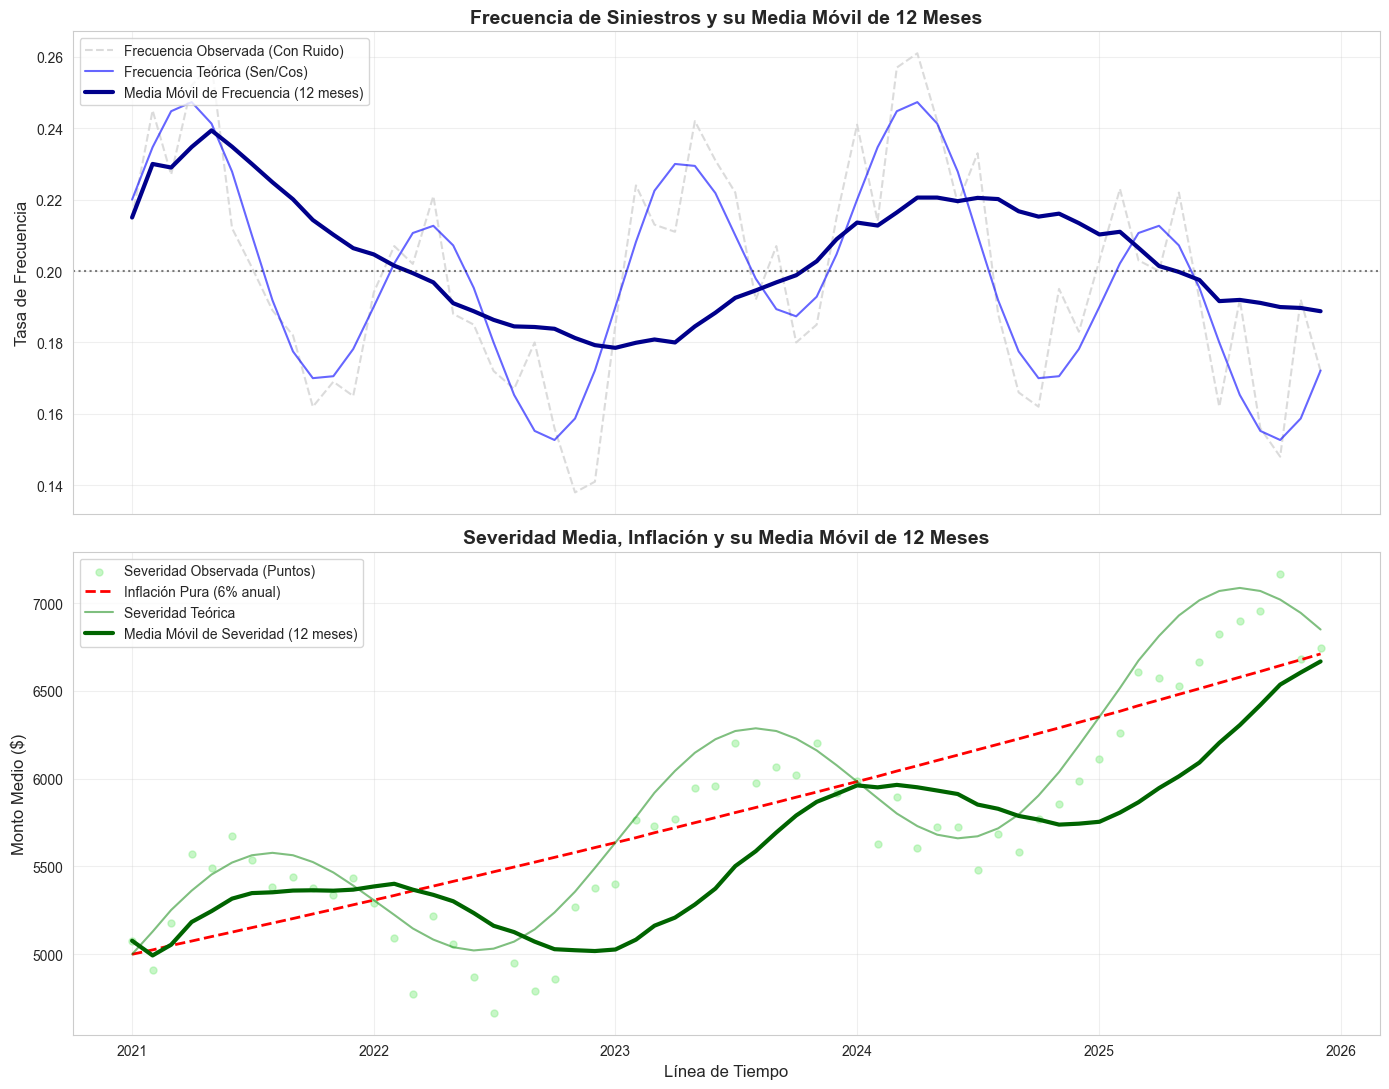

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. RECREACIÓN DE LOS DATOS (Paso anterior)
# ==========================================
np.random.seed(42)
meses = pd.date_range(start="2021-01-01", end="2025-12-01", freq="MS")
n_meses = len(meses)
t = np.arange(n_meses)

# Frecuencia
frecuencia_base = 0.20
estacionalidad_anual = np.sin(2 * np.pi * t / 12) * 0.15
ciclo_plurianual = np.cos(2 * np.pi * t / 36) * 0.10
frecuencia_teorica = frecuencia_base * (1 + estacionalidad_anual + ciclo_plurianual)
exposicion = 1000
n_siniestros_simulados = np.random.poisson(frecuencia_teorica * exposicion)
frecuencia_observada = n_siniestros_simulados / exposicion

# Severidad / Inflación
inflacion_anual = 0.06
inflacion_mensual = inflacion_anual / 12
inflacion_acumulada = (1 + inflacion_mensual) ** t
ciclo_costos = np.sin(2 * np.pi * t / 24) * 0.08
severidad_base = 5000
severidad_teorica = severidad_base * inflacion_acumulada * (1 + ciclo_costos)

severidad_simulada = []
for i, n_sin in enumerate(n_siniestros_simulados):
    if n_sin > 0:
        mu = np.log(severidad_teorica[i]) - 0.1
        montos = np.random.lognormal(mu, 0.4, n_sin)
        severidad_simulada.append(montos.mean())
    else:
        severidad_simulada.append(0)

# Crear DataFrame
df = pd.DataFrame({
    'Frecuencia_Teorica': frecuencia_teorica,
    'Frecuencia_Observada': frecuencia_observada,
    'Inflacion_Pura': severidad_base * inflacion_acumulada,
    'Severidad_Teorica_Con_Ciclo': severidad_teorica,
    'Severidad_Observada': severidad_simulada
}, index=meses)

# ==========================================
# 2. CÁLCULO DE MEDIAS MÓVILES (NUEVO)
# ==========================================
# min_periods=1 evita que los primeros 11 meses aparezcan vacíos (NaN)
df['Frecuencia_MA12'] = df['Frecuencia_Observada'].rolling(window=12, min_periods=1).mean()
df['Severidad_MA12'] = df['Severidad_Observada'].rolling(window=12, min_periods=1).mean()


# ==========================================
# 3. GRÁFICAS CON MEDIAS MÓVILES
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

# --- GRÁFICA 1: FRECUENCIA ---
axes[0].plot(df.index, df['Frecuencia_Observada'], color='lightgray', linestyle='--', alpha=0.8, label='Frecuencia Observada (Con Ruido)')
axes[0].plot(df.index, df['Frecuencia_Teorica'], color='blue', linewidth=1.5, alpha=0.6, label='Frecuencia Teórica (Sen/Cos)')
# Agregar Media Móvil
axes[0].plot(df.index, df['Frecuencia_MA12'], color='darkblue', linewidth=3, label='Media Móvil de Frecuencia (12 meses)')

axes[0].axhline(frecuencia_base, color='black', linestyle=':', alpha=0.5)
axes[0].set_title('Frecuencia de Siniestros y su Media Móvil de 12 Meses', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Tasa de Frecuencia', fontsize=12)
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# --- GRÁFICA 2: SEVERIDAD E INFLACIÓN ---
axes[1].scatter(df.index, df['Severidad_Observada'], color='lightgreen', alpha=0.5, s=25, label='Severidad Observada (Puntos)')
axes[1].plot(df.index, df['Inflacion_Pura'], color='red', linestyle='--', linewidth=2, label='Inflación Pura (6% anual)')
axes[1].plot(df.index, df['Severidad_Teorica_Con_Ciclo'], color='green', linewidth=1.5, alpha=0.5, label='Severidad Teórica')
# Agregar Media Móvil
axes[1].plot(df.index, df['Severidad_MA12'], color='darkgreen', linewidth=3, label='Media Móvil de Severidad (12 meses)')

axes[1].set_title('Severidad Media, Inflación y su Media Móvil de 12 Meses', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Monto Medio ($)', fontsize=12)
axes[1].set_xlabel('Línea de Tiempo', fontsize=12)
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()